In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the CSV
path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  HourlyWindDirection  \
0                         0.0            16.093                  0.0   
1                         0.0            16.093    

In [4]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

19 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


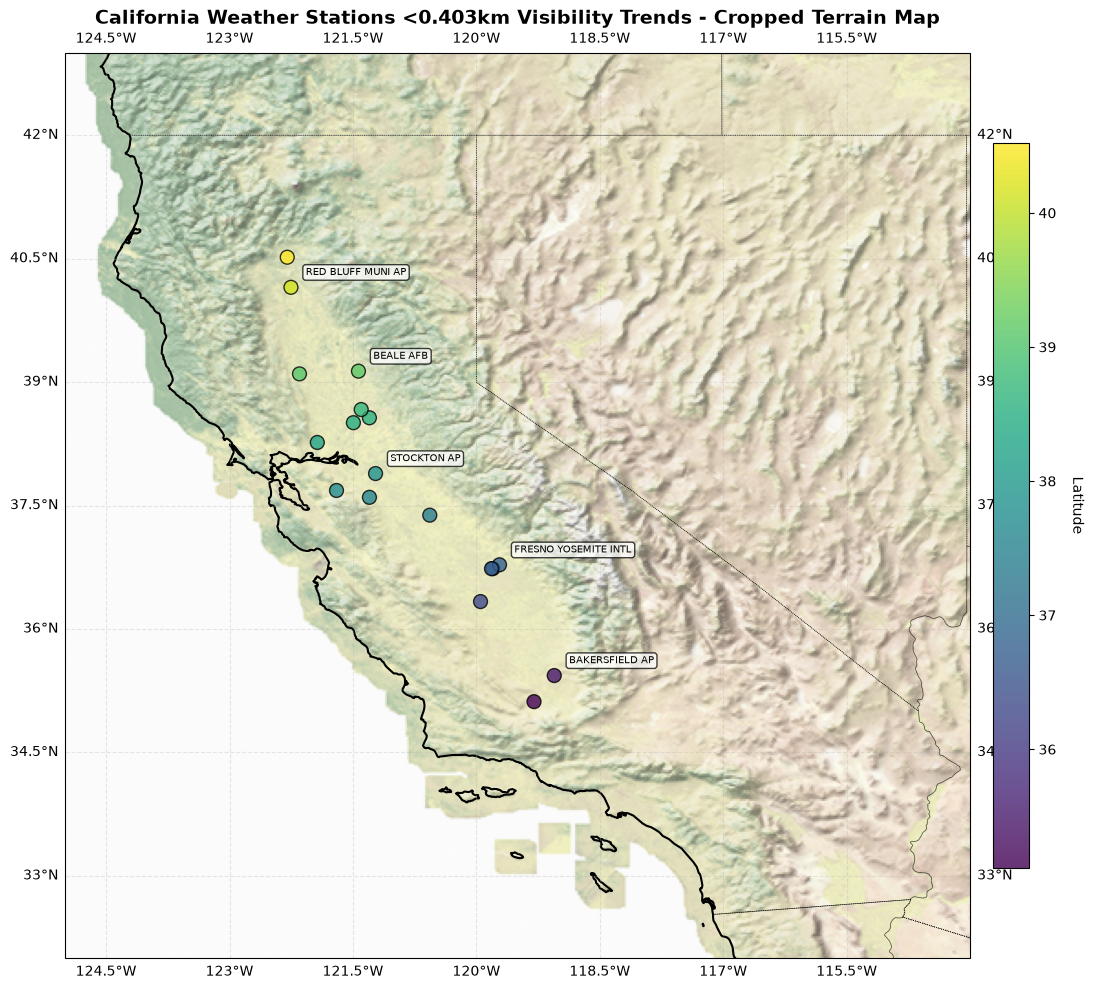

In [5]:
flagged_stations = {
    'FRESNO YOSEMITE INTL',
    'BAKERSFIELD AP',
    'BEALE AFB',
    'RED BLUFF MUNI AP',
    'STOCKTON AP',
    'SACRAMENTO METROPOLITAN AP'
}

# Same station plot, but crop the topography image to California extent first
lon_min, lon_max, lat_min, lat_max = -125, -114, 32, 43

img_path = 'E:/Central Valley Fog/NE1_LR_LC_SR/NE1_LR_LC_SR.TIF'
if not os.path.exists(img_path):
    img_path = '/Volumes/disk1/Central Valley Fog/NE1_LR_LC_SR/NE1_LR_LC_SR.TIF'


# img_path = 'E:/Central Valley Fog/topography_HQ/NE1_HR_LC_SR_W.TIF'
# if not os.path.exists(img_path):
#     img_path = '/Volumes/disk1/Central Valley Fog/topography_HQ/NE1_HR_LC_SR_W.TIF'

img = plt.imread(img_path)

# NE1_LR_LC_SR is global (assumed lon: -180..180, lat: -90..90)
h, w = img.shape[:2]
x0 = int((lon_min + 180) / 360 * w)
x1 = int((lon_max + 180) / 360 * w)
y0 = int((90 - lat_max) / 180 * h)
y1 = int((90 - lat_min) / 180 * h)

x0, x1 = max(0, x0), min(w, x1)
y0, y1 = max(0, y0), min(h, y1)

img_crop = img[y0:y1, x0:x1]

station_locs_ca = station_locations.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.8)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Use cropped image only
ax.imshow(
    img_crop,
    origin='upper',
    transform=ccrs.PlateCarree(),
    extent=[lon_min, lon_max, lat_min, lat_max],
    zorder=0
)

scatter = ax.scatter(
    station_locs_ca['LONGITUDE'],
    station_locs_ca['LATITUDE'],
    s=100,
    c=station_locs_ca['LATITUDE'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1,
    transform=ccrs.PlateCarree(),
    zorder=5,
    alpha=0.8
)

for _, row in station_locs_ca.iterrows():
    if row['STATION'] in flagged_stations:
        ax.text(
            row['LONGITUDE'] + 0.18,
            row['LATITUDE'] + 0.15,
            row['STATION'],
            transform=ccrs.PlateCarree(),
            fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75)
        )

cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Latitude', rotation=270, labelpad=20)

ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
plt.title('California Weather Stations <0.403km Visibility Trends - Cropped Terrain Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

c:\Users\Work Account\miniconda3\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (131220000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


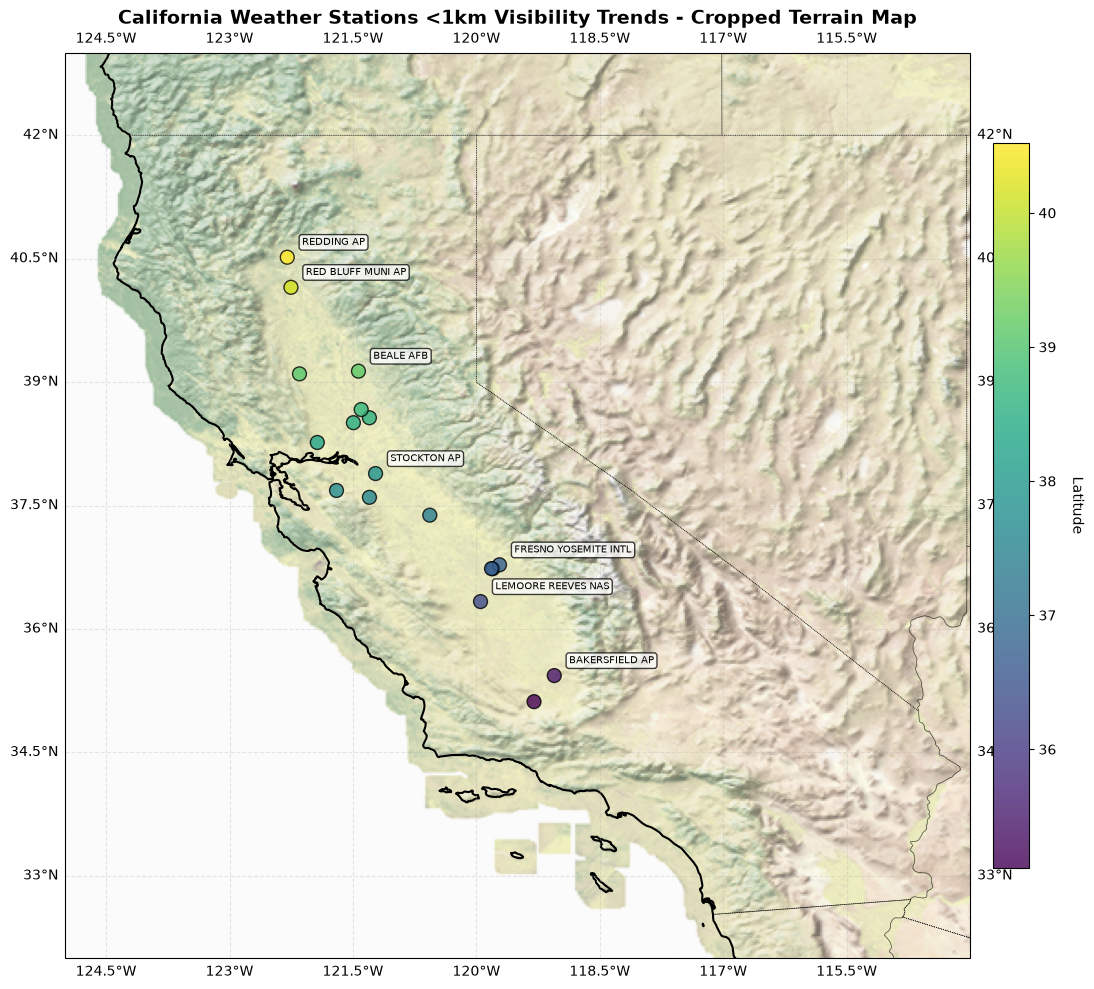

In [9]:
flagged_stations = {
    'FRESNO YOSEMITE INTL',
    'BAKERSFIELD AP',
    'RED BLUFF MUNI AP',
    'STOCKTON AP',
    'BEALE AFB',
    'LEMOORE REEVES NAS',
    'SACRAMENTO METROPOLITAN AP',
    'REDDING AP'

}

# Same station plot, but crop the topography image to California extent first
lon_min, lon_max, lat_min, lat_max = -125, -114, 32, 43

img_path = 'E:/Central Valley Fog/NE1_LR_LC_SR/NE1_LR_LC_SR.TIF'
if not os.path.exists(img_path):
    img_path = '/Volumes/disk1/Central Valley Fog/NE1_LR_LC_SR/NE1_LR_LC_SR.TIF'

img = plt.imread(img_path)

# # NE1_LR_LC_SR is global (assumed lon: -180..180, lat: -90..90)
# h, w = img.shape[:2]
# x0 = int((lon_min + 180) / 360 * w)
# x1 = int((lon_max + 180) / 360 * w)
# y0 = int((90 - lat_max) / 180 * h)
# y1 = int((90 - lat_min) / 180 * h)

# x0, x1 = max(0, x0), min(w, x1)
# y0, y1 = max(0, y0), min(h, y1)

# img_crop = img[y0:y1, x0:x1]

station_locs_ca = station_locations.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.8)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Use cropped image only
ax.imshow(
    img_crop,
    origin='upper',
    transform=ccrs.PlateCarree(),
    extent=[lon_min, lon_max, lat_min, lat_max],
    zorder=0
)

scatter = ax.scatter(
    station_locs_ca['LONGITUDE'],
    station_locs_ca['LATITUDE'],
    s=100,
    c=station_locs_ca['LATITUDE'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1,
    transform=ccrs.PlateCarree(),
    zorder=5,
    alpha=0.8
)

for _, row in station_locs_ca.iterrows():
    if row['STATION'] in flagged_stations:
        ax.text(
            row['LONGITUDE'] + 0.18,
            row['LATITUDE'] + 0.15,
            row['STATION'],
            transform=ccrs.PlateCarree(),
            fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75)
        )

cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Latitude', rotation=270, labelpad=20)

ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
plt.title('California Weather Stations <1km Visibility Trends - Cropped Terrain Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Save the cropped topography image to a file
crop_out_path = os.path.join(os.path.dirname(img_path), "NE1_LR_LC_SR_CA_crop.png")
plt.imsave(crop_out_path, img_crop)

print(f"Saved cropped topography image to: {crop_out_path}")
print(f"Image shape: {img_crop.shape}")

Saved cropped topography image to: E:/Central Valley Fog/NE1_LR_LC_SR\NE1_LR_LC_SR_CA_crop.png
Image shape: (495, 495, 3)
